# PINN

In [46]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jnp_zeros, jn

class SinActivation(nn.Module):
    def __init__(self):
        super(SinActivation, self).__init__()

    def forward(self, x):
        return torch.sin(x)

class CylPINN(nn.Module):
    def __init__(self, m=1):
        super().__init__()
        self.m = m
        self.net = nn.Sequential(
            nn.Linear(2, 64), SinActivation(),
            nn.Linear(64, 64), SinActivation(),
            nn.Linear(64, 64), SinActivation(),
            nn.Linear(64, 64), SinActivation(),
            nn.Linear(64, 1)
        )

    def forward(self, rho, phi):
        x = torch.cat([rho, phi/(2*np.pi)], dim=-1)
        amp = self.net(x)
        # hard constraint for m = 1 regularity: \psi(\rho=0) = 0 and correct near-axis behavior+
        return amp*rho*torch.cos(phi)

def compute_polar_laplacian(model, rho, phi):
    rho_req = rho.clone().detach().requires_grad_(True)
    phi_req = phi.clone().detach().requires_grad_(True)

    # solution
    psi = model(rho_req, phi_req)

    # 1st derivatives
    psi_rho = torch.autograd.grad(psi.sum(), rho_req, create_graph=True, retain_graph=True)[0]
    psi_phi = torch.autograd.grad(psi.sum(), phi_req, create_graph=True, retain_graph=True)[0]

    # 2nd derivatives
    psi_rhorho = torch.autograd.grad(psi_rho.sum(), rho_req, create_graph=True, retain_graph=True)[0]
    psi_phiphi = torch.autograd.grad(psi_phi.sum(), phi_req, create_graph=True, retain_graph=True)[0]

    # the left side of the Helmholtz equation with \epsilon regularization of zeros
    lap = psi_rhorho + psi_rho/(rho_req + 1e-8) + psi_phiphi/(rho_req**2 + 1e-8)
    return lap

# power usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# proceeded NN for m = 1 with L-BFGS optimzer
model = CylPINN(m=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

# analytical solution for comparison: TE_{11}
# wavenumber
kc_te11 = 1.841184
kc2_param = torch.tensor(kc_te11**2, device=device, dtype=torch.float32)

# training data
# total points
N_col = 10000
# interior: high density, most valuable solution points
rho_int = (torch.rand((9*N_col//10, 1), device=device, dtype=torch.float32)*0.95).requires_grad_(True)
phi_int = (torch.rand((9*N_col//10, 1), device=device, dtype=torch.float32)*2*np.pi).requires_grad_(True)

# waveguide PEC boundary: no free charges (zero amplitude at the boundary)
rho_bnd = torch.ones((N_col//10, 1), device=device, dtype=torch.float32).requires_grad_(True)
phi_bnd = (torch.rand((N_col//10, 1), device=device, dtype=torch.float32)*2*np.pi).requires_grad_(True)

best_loss = float("inf")

# Store loss history for plotting
loss_history = []
pde_loss_history = []
bnd_loss_history = []

for epoch in range(4000):
    optimizer.zero_grad()

    # pde residual: interior points
    psi_int = model(rho_int, phi_int)
    lap_int = compute_polar_laplacian(model, rho_int, phi_int)
    l_pde = torch.mean((lap_int + kc2_param*psi_int)**2)

    # TE_{11} Neumann boundary conditions at waveguide wall (\rho = 1)
    psi_bnd = model(rho_bnd, phi_bnd)
    psi_rho_bnd = torch.autograd.grad(psi_bnd.sum(), rho_bnd, retain_graph=True, create_graph=True)[0]
    l_bnd = torch.mean(psi_rho_bnd**2)

    # total loss
    loss = l_pde + 100.0*l_bnd

    loss.backward()
    optimizer.step()

    # store losses for plotting
    loss_history.append(loss.item())
    pde_loss_history.append(l_pde.item())
    bnd_loss_history.append(l_bnd.item())

    # update best loss
    if loss.item() < best_loss:
        best_loss = loss.item()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.2e} | PDE: {l_pde.item():.2e} | Bnd: {l_bnd.item():.2e}")

print(f"\nFinal Loss: {best_loss:.2e}")
print("PINN converged to TE11 mode!")

Using device: cpu
Analytical TE11 kc = 1.841184
Training PINN...
Epoch    0 | Loss: 2.37e+03 | PDE: 2.37e+03 | Bnd: 1.88e-04
Epoch  500 | Loss: 1.44e-03 | PDE: 1.12e-03 | Bnd: 3.20e-06
Epoch 1000 | Loss: 9.99e-04 | PDE: 8.43e-04 | Bnd: 1.56e-06
Epoch 1500 | Loss: 6.23e-04 | PDE: 5.61e-04 | Bnd: 6.16e-07
Epoch 2000 | Loss: 3.45e-04 | PDE: 3.24e-04 | Bnd: 2.06e-07
Epoch 2500 | Loss: 1.63e-04 | PDE: 1.57e-04 | Bnd: 6.20e-08
Epoch 3000 | Loss: 6.41e-05 | PDE: 6.20e-05 | Bnd: 2.05e-08
Epoch 3500 | Loss: 2.17e-05 | PDE: 2.07e-05 | Bnd: 9.73e-09

Final Loss: 1.24e-05
PINN converged to TE11 mode!


# Visulation


 Loss curves


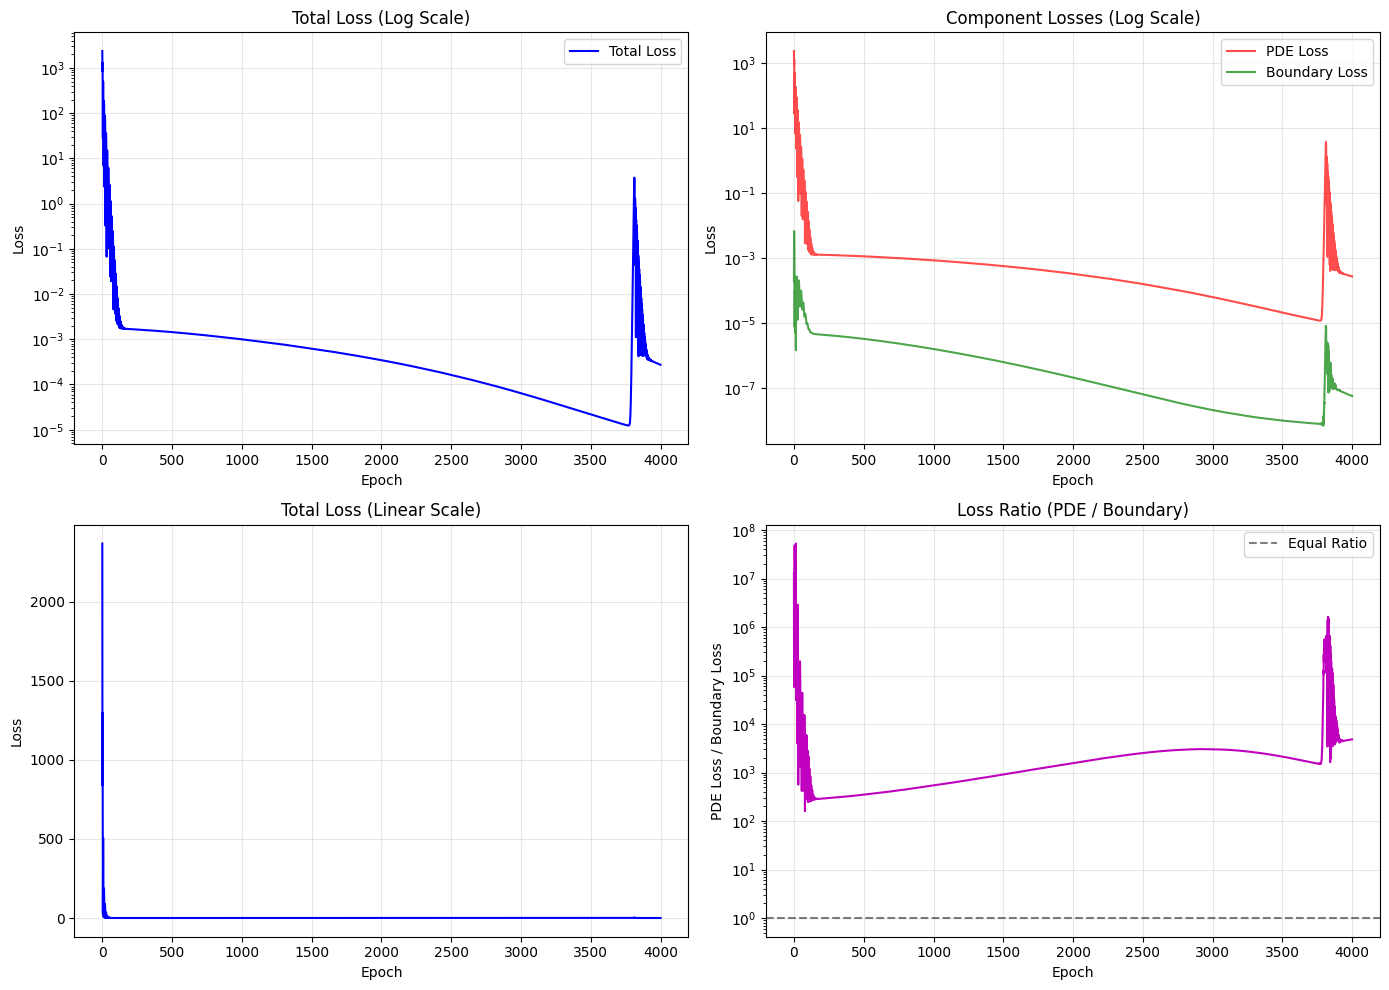

In [49]:
# los curve plot
print("\n Loss curves")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# total loss (semilogy)
ax1 = axes[0, 0]
ax1.semilogy(loss_history, 'b-', linewidth=1.5, label='Total Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Total Loss (Log Scale)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# PDE and boundary losses (semilogy)
ax2 = axes[0, 1]
ax2.semilogy(pde_loss_history, 'r-', linewidth=1.5, label='PDE Loss', alpha=0.7)
ax2.semilogy(bnd_loss_history, 'g-', linewidth=1.5, label='Boundary Loss', alpha=0.7)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Component Losses (Log Scale)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# total loss (linear)
ax3 = axes[1, 0]
ax3.plot(loss_history, 'b-', linewidth=1.5)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss')
ax3.set_title('Total Loss (Linear Scale)')
ax3.grid(True, alpha=0.3)

# loss ratio (PDE vs boundary)
ax4 = axes[1, 1]
pde_np = np.array(pde_loss_history)
bnd_np = np.array(bnd_loss_history)
loss_ratio = pde_np/(bnd_np + 1e-12)
ax4.semilogy(loss_ratio, 'm-', linewidth=1.5)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('PDE Loss / Boundary Loss')
ax4.set_title('Loss Ratio (PDE / Boundary)')
ax4.grid(True, alpha=0.3)
ax4.axhline(y=1.0, color='k', linestyle='--', alpha=0.5, label='Equal Ratio')
ax4.legend()

plt.tight_layout()
plt.show()

In [50]:
# validation
print("\n Validation")

rho_test = torch.linspace(0.01, 1.0, 512, device=device).unsqueeze(1)
test_angle = np.pi # for solution check

phi_test = torch.full_like(rho_test, test_angle)

with torch.no_grad():
    psi_pinn = model(rho_test, phi_test).cpu().numpy().flatten()

rho_np = rho_test.cpu().numpy().flatten()

# analytical solution for TE11 mode (with \cos(\phi) angular dependence)
psi_analytical = jn(1, kc_te11*rho_np)*np.cos(test_angle)

# normalization
max_pinn = np.max(np.abs(psi_pinn)) + 1e-12
max_anal = np.max(np.abs(psi_analytical)) + 1e-12
psi_pinn_norm = psi_pinn/max_pinn
psi_anal_norm = psi_analytical/max_anal

# L2 error
l2_error = np.sqrt(np.mean((psi_pinn_norm - psi_anal_norm)**2))

print(f"Test angle = {test_angle:.4f} rad ({test_angle*180/np.pi:.1f}°)")
print(f"L2 relative error: {l2_error:.2e}")

# periodicity check
phi1 = torch.zeros_like(rho_test)
phi2 = torch.full_like(rho_test, 2*np.pi)

with torch.no_grad():
    diff = torch.abs(model(rho_test, phi1) - model(rho_test, phi2)).max().item()

print(f"Periodicity error (max diff): {diff:.2e}")


 Validation
Test angle = 3.1416 rad (180.0°)
L2 relative error: 1.31e+00
Periodicity error (max diff): 3.98e-04


In [51]:
# phase decision block

# additional verification step that checks angular dependence at fixed radius
rho_fixed = 0.5 # middle
phi_angles = torch.linspace(0, 2*np.pi, 200, device=device).unsqueeze(1)
rho_fixed_tensor = torch.full_like(phi_angles, rho_fixed)

with torch.no_grad():
    psi_angular = model(rho_fixed_tensor, phi_angles).cpu().numpy().flatten()

# analytical \cos(\phi) dependence
phi_np = phi_angles.cpu().numpy().flatten()
analytical_angular = jn(1, kc_te11*rho_fixed)*np.cos(phi_np)

# normalization
max_psi = np.max(np.abs(psi_angular)) + 1e-12
max_analytical = np.max(np.abs(analytical_angular)) + 1e-12
psi_angular_norm = psi_angular/max_psi
analytical_angular_norm = analytical_angular/max_analytical

# computing correlation to verify \cos(\phi) dependence
correlation = np.corrcoef(psi_angular_norm, analytical_angular_norm)[0, 1]

print(f"\n Angular dependence verification")
print(f"Correlation with cos: {correlation:.6f}")

# checking if there is any \sin(\phi) component mixed in
sin_component = np.sin(phi_np)
sin_correlation = np.corrcoef(psi_angular_norm, sin_component)[0, 1]
print(f"Correlation with sin: {abs(sin_correlation):.6f}")

if abs(sin_correlation) < 0.1:
    print("PINN learned a pure cos TE11 mode as expected")
else:
    print("PINN shows some sin mixing")


 Angular dependence verification
Correlation with cos: -0.993376
Correlation with sin: 0.018128
PINN learned a pure cos TE11 mode as expected


<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_19679/2505769789.py:22: SyntaxWarning: invalid escape sequence '\p'
  plt.colorbar(label='Analytical $\psi$ (H$_z$)')
/tmp/ipykernel_19679/2505769789.py:38: SyntaxWarning: invalid escape sequence '\p'
  plt.colorbar(label='PINN $\psi$')


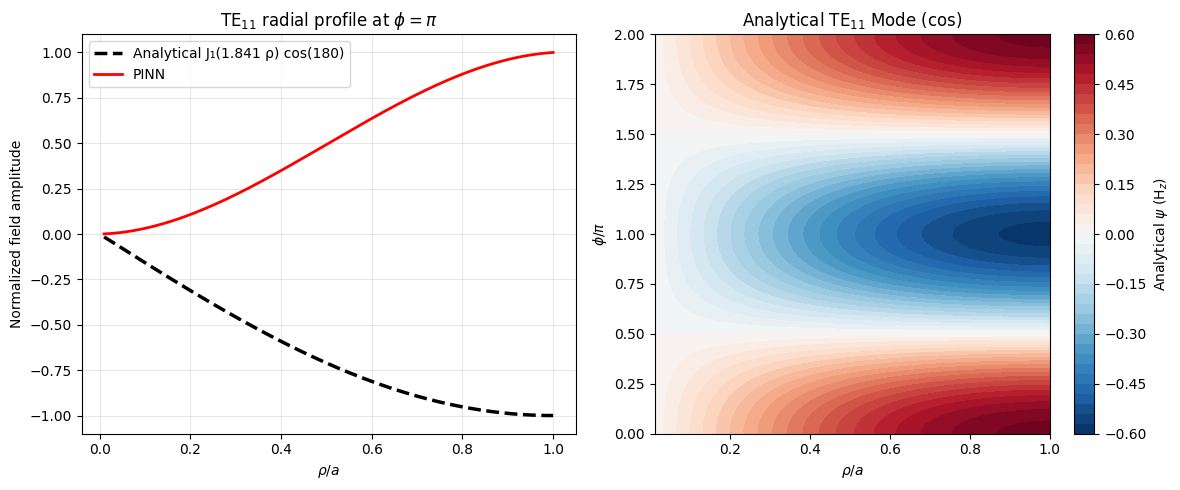

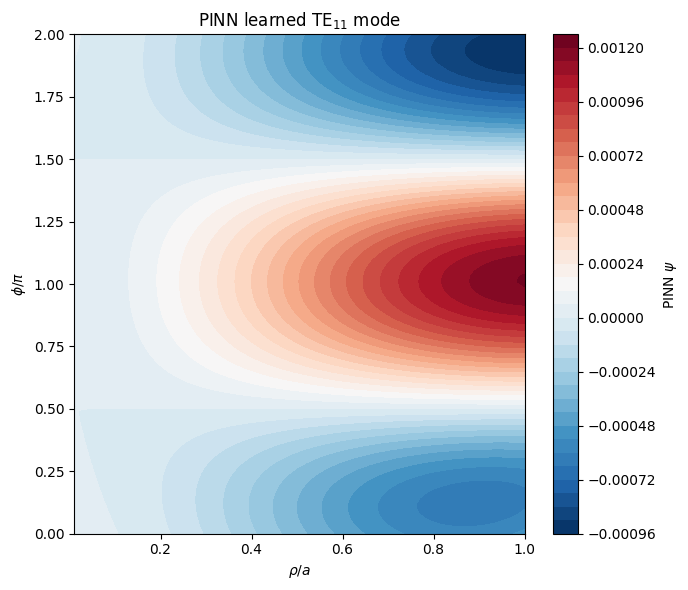

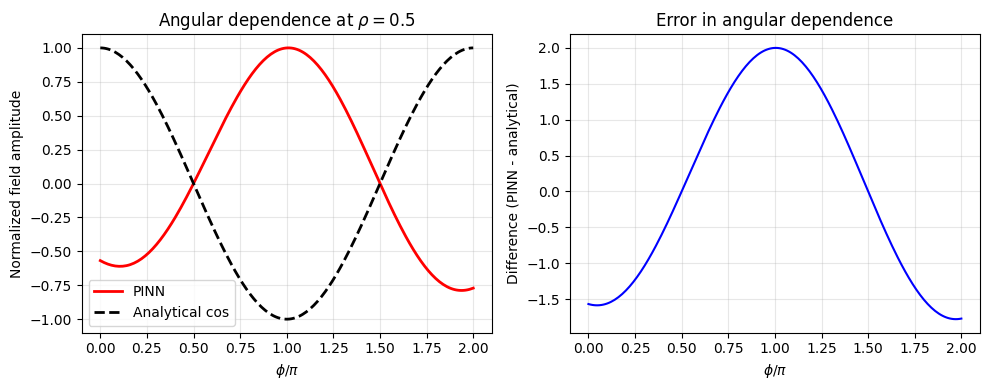

In [52]:
# solution plots

plt.figure(figsize=(12, 5))

# radial profile comparison (at 180 deg)
plt.subplot(1, 2, 1)
plt.plot(rho_np, psi_anal_norm, 'k--', lw=2.5,
         label=f'Analytical J₁({kc_te11:.3f} ρ) cos(180)')
plt.plot(rho_np, psi_pinn_norm, 'r-', lw=2.0, label='PINN')
plt.xlabel(r'$\rho/a$')
plt.ylabel('Normalized field amplitude')
plt.title(f'TE$_{{11}}$ radial profile at $\\phi=\\pi$')
plt.grid(alpha=0.3)
plt.legend()

# 2D analytical pattern (cos form)
R, PHI = np.meshgrid(np.linspace(0.01, 1.0, 100), np.linspace(0, 2*np.pi, 100))
PSI_ANAL = jn(1, kc_te11*R)*np.cos(PHI)

plt.subplot(1, 2, 2)
plt.contourf(R, PHI / np.pi, PSI_ANAL, levels=40, cmap='RdBu_r')
plt.colorbar(label='Analytical $\psi$ (H$_z$)')
plt.xlabel(r'$\rho/a$')
plt.ylabel(r'$\phi/\pi$')
plt.title('Analytical TE$_{11}$ Mode (cos)')
plt.tight_layout()
plt.show()

# 2D PINN pattern
rho_grid = torch.tensor(R.flatten(), device=device, dtype=torch.float32).unsqueeze(1)
phi_grid = torch.tensor(PHI.flatten(), device=device, dtype=torch.float32).unsqueeze(1)

with torch.no_grad():
    psi_grid = model(rho_grid, phi_grid).cpu().numpy().reshape(100, 100)

plt.figure(figsize=(7, 6))
plt.contourf(R, PHI / np.pi, psi_grid, levels=40, cmap='RdBu_r')
plt.colorbar(label='PINN $\psi$')
plt.xlabel(r'$\rho/a$')
plt.ylabel(r'$\phi/\pi$')
plt.title('PINN learned TE$_{11}$ mode')
plt.tight_layout()
plt.show()

# angular dependence plot at fixed radius
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(phi_np/np.pi, psi_angular_norm, 'r-', lw=2, label='PINN')
plt.plot(phi_np/np.pi, analytical_angular_norm, 'k--', lw=2, label='Analytical cos')
plt.xlabel(r'$\phi/\pi$')
plt.ylabel('Normalized field amplitude')
plt.title(f'Angular dependence at $\\rho={rho_fixed}$')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(phi_np/np.pi, psi_angular_norm - analytical_angular_norm, 'b-', lw=1.5)
plt.xlabel(r'$\phi/\pi$')
plt.ylabel('Difference (PINN - analytical)')
plt.title('Error in angular dependence')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
# we observe a single half-revolution (\pi) shift compared to the analytical solution
# comparative analysis shows that the angular dependency was restored up to the constant phase shift that is not crucial to the prepared PINN